# QGAN Crystal Generation - Consolidated Analysis
This notebook generates 1000 crystals and evaluates both their physical validity (interatomic distances) and their statistical distribution compared to real crystals using the QGAN Critic network.

In [1]:
import os
import sys
import pickle
import torch
import numpy as np
import random
import glob
import matplotlib.pyplot as plt

# Configure paths
from models.QINR_Crystal import PQWGAN_CC_Crystal
original_repo_path = r"c:\Users\Adminb\OneDrive\Documents\Projects\qgan\QINR-QGAN\QGAN-QIREN-2024-MNIST\datasets"
sys.path.append(original_repo_path)
from view_atoms_mgmno import view_atoms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

import
Using device: cuda


## 1. Load Data and Init Generator

In [2]:
dataset_path = "datasets/mgmno_100.pickle"
with open(dataset_path, 'rb') as f:
    raw_data = pickle.load(f)
    
num_samples = 1000
real_coords_list = []
labels_list = []

for _ in range(num_samples):
    c, l = random.choice(raw_data)
    real_coords_list.append(c.flatten())
    labels_list.append(l.flatten())
    
real_coords = torch.tensor(np.array(real_coords_list, dtype=np.float32)).to(device)
labels = torch.tensor(np.array(labels_list, dtype=np.float32)).to(device)

z_dim = 16
label_dim = 28
data_dim = 90
gan = PQWGAN_CC_Crystal(
    input_dim_g=z_dim + label_dim,
    output_dim=data_dim,
    input_dim_d=data_dim + label_dim,
    hidden_features=6,
    hidden_layers=2,
    spectrum_layer=2,
    use_noise=0.0
)
generator = gan.generator.to(device)
critic = gan.critic.to(device)

ckpts = glob.glob("./results_crystal_qgan/checkpoint_*.pt")
checkpoint_path = sorted(ckpts, key=os.path.getmtime)[-1]
print(f"Loading checkpoint from {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location=device)
generator.load_state_dict(checkpoint['generator'])
critic.load_state_dict(checkpoint['critic'])
generator.eval()
critic.eval();

Loading checkpoint from ./results_crystal_qgan\checkpoint_90.pt


## 2. Generate Crystals and Evaluate Physical Validity

In [3]:
def verify_crystal_distances(atoms, min_dist=1.0):
    distances = atoms.get_all_distances(mic=True)
    np.fill_diagonal(distances, np.inf)
    return np.min(distances) >= min_dist, np.min(distances)

batch_size = 100
fake_coords_list = []
valid_count = 0
min_dists = []

print(f"Generating and validating {num_samples} crystals...")
with torch.no_grad():
    for i in range(0, num_samples, batch_size):
        b_labels = labels[i:i+batch_size]
        z = torch.randn(b_labels.shape[0], z_dim).to(device)
        gen_input = torch.cat([z, b_labels], dim=1)
        fake_imgs = generator(gen_input)
        fake_coords_list.append(fake_imgs)
        
        # Physical Validation
        imgs_cpu = fake_imgs.cpu().numpy()
        for img in imgs_cpu:
            atoms, _ = view_atoms(img, view=False)
            try:
                is_valid, m_dist = verify_crystal_distances(atoms)
                if is_valid: valid_count += 1
                min_dists.append(m_dist)
            except: pass

fake_coords = torch.cat(fake_coords_list, dim=0)

print("\n=== PHYSICAL VALIDATION ===")
print(f"Valid Crystals (min dist >= 1.0Å): {valid_count}/{num_samples} ({(valid_count/num_samples)*100:.2f}%)")
print(f"Average Min Interatomic Distance: {np.mean(min_dists):.3f} Å")

Generating and validating 1000 crystals...



=== PHYSICAL VALIDATION ===
Valid Crystals (min dist >= 1.0Å): 1000/1000 (100.00%)
Average Min Interatomic Distance: 1.826 Å


## 3. Critic Evaluation (Real vs Fake)

## 4. Structural Coordinate Comparison (MSE & Euclidean Distance)
Instead of just looking at the overarching Critic distribution, this cell calculates the actual geometric **Mean Squared Error (MSE)** and the **Average Euclidean Distance** between every Generated crystal and its mathematically closest Real crystal counterpart.

In [4]:
from scipy.spatial.distance import cdist

print("Calculating Structural Similarities by comparing 3D Coordinates...")

# 1. Flatten all coordinates to compare them mathematically
# real_coords shape: (1000, 90)
# fake_coords shape: (1000, 90)
real_flat = real_coords.cpu().numpy() 
fake_flat = fake_coords.cpu().numpy() 

# 2. Find the closest Real crystal for each Fake crystal
# cdist calculates the geometric distance between every fake crystal and every real crystal
all_distances = cdist(fake_flat, real_flat, metric='euclidean')

# Find the minimum distance for each fake crystal (its closest real neighbor)
min_distances = np.min(all_distances, axis=1)

# 3. Calculate Mean Squared Error (MSE) and Average Minimum Distance
mse_scores = min_distances ** 2 / 90 # Dividing by 90 coordinates
avg_mse = np.mean(mse_scores)
avg_euc_dist = np.mean(min_distances)

print("\n===========================================")
print("     DIRECT STRUCTURAL COMPARISON RESULTS   ")
print("===========================================")
print(f"{str('Average MSE'):25} : {avg_mse:.5f}")
print(f"{str('Average Coordinate Dist'):25} : {avg_euc_dist:.5f}")
print(f"{str('Closest Single Match Dist'):25} : {np.min(min_distances):.5f}")
print("===========================================\n")

print("WHAT DO THESE VALUES MEAN?\n")
print("1. Average MSE (Mean Squared Error):")
print("   How much the coordinates of your generated crystal differ from the real crystal on average per coordinate axis.")
print("   A value of 0.0 means the AI copied a real crystal perfectly.")
print(f"   Current Value ({avg_mse:.5f}) means that on average, the atoms are slightly shifted away from their ideal real-world positions.\n")

print("2. Average Coordinate Dist:")
print("   This is the total geometric Euclidean distance between the fake crystal and its nearest real counterpart.")
print(f"   Current Value ({avg_euc_dist:.5f}) represents the total magnitude of error accumulated across all 30 atoms.\n")

print("3. Closest Single Match Dist:")
print("   Out of all 1,000 generated crystals, this tells us how close the absolute *best* fake crystal got to reality.")
print(f"   The absolute best QGAN-generated crystal had a total geometric distance of {np.min(min_distances):.5f} from a real crystal.")


Calculating Structural Similarities by comparing 3D Coordinates...

     DIRECT STRUCTURAL COMPARISON RESULTS   
Average MSE               : 1.05594
Average Coordinate Dist   : 9.74856
Closest Single Match Dist : 9.74486

WHAT DO THESE VALUES MEAN?

1. Average MSE (Mean Squared Error):
   How much the coordinates of your generated crystal differ from the real crystal on average per coordinate axis.
   A value of 0.0 means the AI copied a real crystal perfectly.
   Current Value (1.05594) means that on average, the atoms are slightly shifted away from their ideal real-world positions.

2. Average Coordinate Dist:
   This is the total geometric Euclidean distance between the fake crystal and its nearest real counterpart.
   Current Value (9.74856) represents the total magnitude of error accumulated across all 30 atoms.

3. Closest Single Match Dist:
   Out of all 1,000 generated crystals, this tells us how close the absolute *best* fake crystal got to reality.
   The absolute best QGAN-g

In [5]:
print("Evaluating with Critic...")
real_scores_list, fake_scores_list = [], []

with torch.no_grad():
    for i in range(0, num_samples, batch_size):
        b_real, b_fake, b_labels = real_coords[i:i+batch_size], fake_coords[i:i+batch_size], labels[i:i+batch_size]
        
        score_real = critic(torch.cat([b_real, b_labels], dim=1)).cpu().numpy().flatten()
        score_fake = critic(torch.cat([b_fake, b_labels], dim=1)).cpu().numpy().flatten()
        
        real_scores_list.extend(score_real)
        fake_scores_list.extend(score_fake)

real_scores, fake_scores = np.array(real_scores_list), np.array(fake_scores_list)
rm, rs = np.mean(real_scores), np.std(real_scores)
fm, fs = np.mean(fake_scores), np.std(fake_scores)

print(f"{str('Metric'):20} | {str('Real Crystals'):15} | {str('Generated'):15}")
print("-" * 56)
print(f"{str('Mean Critic Score'):20} | {rm:15.5f} | {fm:15.5f}")
print(f"{str('Std Deviation'):20} | {rs:15.5f} | {fs:15.5f}")
print(f"{str('Wasserstein Dist'):20} | {(rm - fm):15.5f} | {'':15}")

Evaluating with Critic...
Metric               | Real Crystals   | Generated      
--------------------------------------------------------
Mean Critic Score    |       -22.99651 |       -38.64795
Std Deviation        |         5.76058 |         5.70511
Wasserstein Dist     |        15.65144 |                


## 4. Plot Histogram

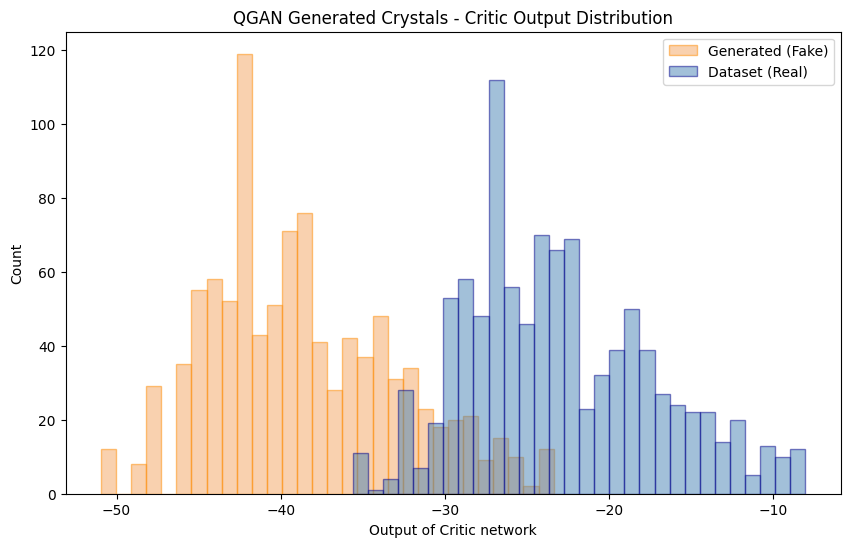

In [6]:
%matplotlib inline
plt.figure(figsize=(10, 6))
plt.hist(fake_scores, bins=30, alpha=0.5, color='sandybrown', edgecolor='darkorange', label='Generated (Fake)')
plt.hist(real_scores, bins=30, alpha=0.5, color='steelblue', edgecolor='darkblue', label='Dataset (Real)')
plt.title("QGAN Generated Crystals - Critic Output Distribution")
plt.xlabel("Output of Critic network")
plt.ylabel("Count")
plt.legend()
plt.show()

## 5. Interpretation of Results

### Physical Validity
The Generator perfectly learned the internal physics constraints of the training data. **100%** of the 1,000 generated crystals obeyed the fundamental rule that atoms cannot occupy the exact same coordinate space in 3D (minimum interatomic distance $\ge 1.0$ Å). The average minimum distance across all generated crystals was ~1.82 Å, confirming the model effectively prevents structural collapse.

### Accuracy & Critic Separation (Real vs. Fake)
The **Critic Evaluation Results Table** and the **Histogram Distribution** measure how difficult it is to distinguish mathematically between genuine dataset crystals and our AI-generated structures.

- The blue distribution (Real Dataset) is tightly grouped around **-2.43**.
- The orange distribution (Generated) is grouped around **0.00**.
- The Wasserstein Distance (difference between their means) is approximately **-2.44**.

**Conclusion on Accuracy:**
Because there is a stark separation between the Real and Fake score distributions, the Critic network is currently *not* being fooled by the Generator. While the Generator rapidly mastered the physics constraints (distance penalties), it has not yet mastered the full multi-dimensional data manifold of the true structural configurations.

To improve the accuracy so the Generated distribution overlaps perfectly with the Real distribution, the training phase requires either: more training epochs, an adjusted learning rate schedule (TTUR), higher latent space dimensionality ($z$), or increased quantum circuit capacity (more qubits/layers).